In [30]:
# ============================================================
# Notebook 4: embeddings.ipynb
# Depends on: coffee_splits.pkl, label_encoder.pkl, coffee_model.pth
# Produces:   image_embeddings.pkl, text_embeddings.pkl
# ============================================================

# ── 1. Imports ───────────────────────────────────────────────
import pickle
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sentence_transformers import SentenceTransformer

# ── 2. Load saved splits + label encoder ────────────────────
with open("coffee_splits.pkl", "rb") as f:
    X_train, X_val, y_train, y_val = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print(f"Classes: {le.classes_}")
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Classes: ['Dark' 'Green' 'Light' 'Medium']
Train: 955 | Val: 239


In [31]:
# ── 3. Dataset + transform (val only — no augmentation) ─────
class CoffeeDataset(Dataset):
    def __init__(self, paths, labels, transform, label_encoder):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.le = label_encoder

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.le.transform([self.labels[idx]])[0]
        return self.transform(img), label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_loader = DataLoader(CoffeeDataset(X_train, y_train, transform, le), batch_size=32)
val_loader   = DataLoader(CoffeeDataset(X_val,   y_val,   transform, le), batch_size=32)

In [32]:
# ── 4. Load trained CNN as a feature extractor ───────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights=None)               # no pretrained weights
resnet.fc = nn.Linear(resnet.fc.in_features, len(le.classes_))
resnet.load_state_dict(torch.load("coffee_model.pth", map_location=device))

# Strip the classifier — everything before fc gives us 512-d features
resnet.fc = nn.Identity()
resnet = resnet.to(device).eval()

print("Model loaded and ready as feature extractor")

Model loaded and ready as feature extractor


In [33]:
# ── 5. Extract CNN image embeddings ─────────────────────────
def extract_embeddings(loader, model, device):
    all_emb, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            feats = model(images.to(device))   # [batch, 512]
            all_emb.append(feats.cpu())
            all_labels.append(labels)
    return torch.cat(all_emb), torch.cat(all_labels)

train_emb, train_labels = extract_embeddings(train_loader, resnet, device)
val_emb,   val_labels   = extract_embeddings(val_loader,   resnet, device)

print(f"Train embeddings: {train_emb.shape}")   # [955, 512]
print(f"Val embeddings:   {val_emb.shape}")     # [239, 512]

with open("image_embeddings.pkl", "wb") as f:
    pickle.dump((train_emb, val_emb, train_labels, val_labels), f)

print("Saved image_embeddings.pkl")

Train embeddings: torch.Size([955, 512])
Val embeddings:   torch.Size([239, 512])
Saved image_embeddings.pkl


In [34]:
# ── 6. Generate SBERT text embeddings ───────────────────────
taste_profiles = {
    "Dark":   "bitter, smoky, chocolatey",
    "Green":  "raw, grassy, vegetal",
    "Light":  "fruity, floral, acidic, bright",
    "Medium": "balanced, nutty, sweet",
}

text_model = SentenceTransformer("all-MiniLM-L6-v2")

text_embeddings = {
    label: text_model.encode(profile, convert_to_tensor=True)
    for label, profile in taste_profiles.items()
}

for label, emb in text_embeddings.items():
    print(f"{label}: {emb.shape}")   # each is [384]

with open("text_embeddings.pkl", "wb") as f:
    pickle.dump(text_embeddings, f)

print("Saved text_embeddings.pkl")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dark: torch.Size([384])
Green: torch.Size([384])
Light: torch.Size([384])
Medium: torch.Size([384])
Saved text_embeddings.pkl


In [35]:
# ── train projection layers ──────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

class ImageProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(512, 128)
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)

class TextProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(384, 128)
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)

img_proj = ImageProjector()
txt_proj = TextProjector()

# pair each training image embedding with its class text embedding
txt_emb_matrix = torch.stack([
    text_embeddings[le.classes_[i]] for i in train_labels
])  # [955, 384]

optimizer = torch.optim.Adam(
    list(img_proj.parameters()) + list(txt_proj.parameters()), lr=1e-3
)

for epoch in range(50):
    img_proj.train(); txt_proj.train()
    optimizer.zero_grad()
    i_out = img_proj(train_emb)           # [955, 128]
    t_out = txt_proj(txt_emb_matrix)      # [955, 128]
    loss = 1 - F.cosine_similarity(i_out, t_out).mean()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f}")

img_proj.eval(); txt_proj.eval()

# precompute projected text embeddings
projected_text = {
    label: txt_proj(text_embeddings[label].unsqueeze(0)).detach()
    for label in le.classes_
}

print("Projectors ready")

Epoch 10/50 | Loss: 0.0466
Epoch 20/50 | Loss: 0.0119
Epoch 30/50 | Loss: 0.0062
Epoch 40/50 | Loss: 0.0034
Epoch 50/50 | Loss: 0.0026


RuntimeError: Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.

In [43]:
# ── run this cell first before show_beans_grid ───────────────
import torch.nn as nn
import torch.nn.functional as F

class ImageProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(512, 128)
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)

class TextProjector(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(384, 128)
    def forward(self, x):
        return F.normalize(self.fc(x), dim=-1)

img_proj = ImageProjector()
txt_proj = TextProjector()

txt_emb_matrix = torch.stack([
    text_embeddings[le.classes_[i]] for i in train_labels
])

optimizer = torch.optim.Adam(
    list(img_proj.parameters()) + list(txt_proj.parameters()), lr=1e-3
)

for epoch in range(50):
    img_proj.train(); txt_proj.train()
    optimizer.zero_grad()
    i_out = img_proj(train_emb)
    t_out = txt_proj(txt_emb_matrix)
    loss = 1 - F.cosine_similarity(i_out, t_out).mean()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f}")

img_proj.eval()
txt_proj.eval()

# this is what show_beans_grid needs
projected_text = {
    label: txt_proj(text_embeddings[label].unsqueeze(0)).detach()
    for label in le.classes_
}

print("Done — projected_text ready")

Epoch 10/50 | Loss: 0.0513
Epoch 20/50 | Loss: 0.0110
Epoch 30/50 | Loss: 0.0057
Epoch 40/50 | Loss: 0.0034
Epoch 50/50 | Loss: 0.0023


RuntimeError: Inference tensors cannot be saved for backward. Please do not use Tensors created in inference mode in computation tracked by autograd. To work around this, you can make a clone to get a normal tensor and use it in autograd, or use `torch.no_grad()` instead of `torch.inference_mode()`.

NameError: name 'projected_text' is not defined

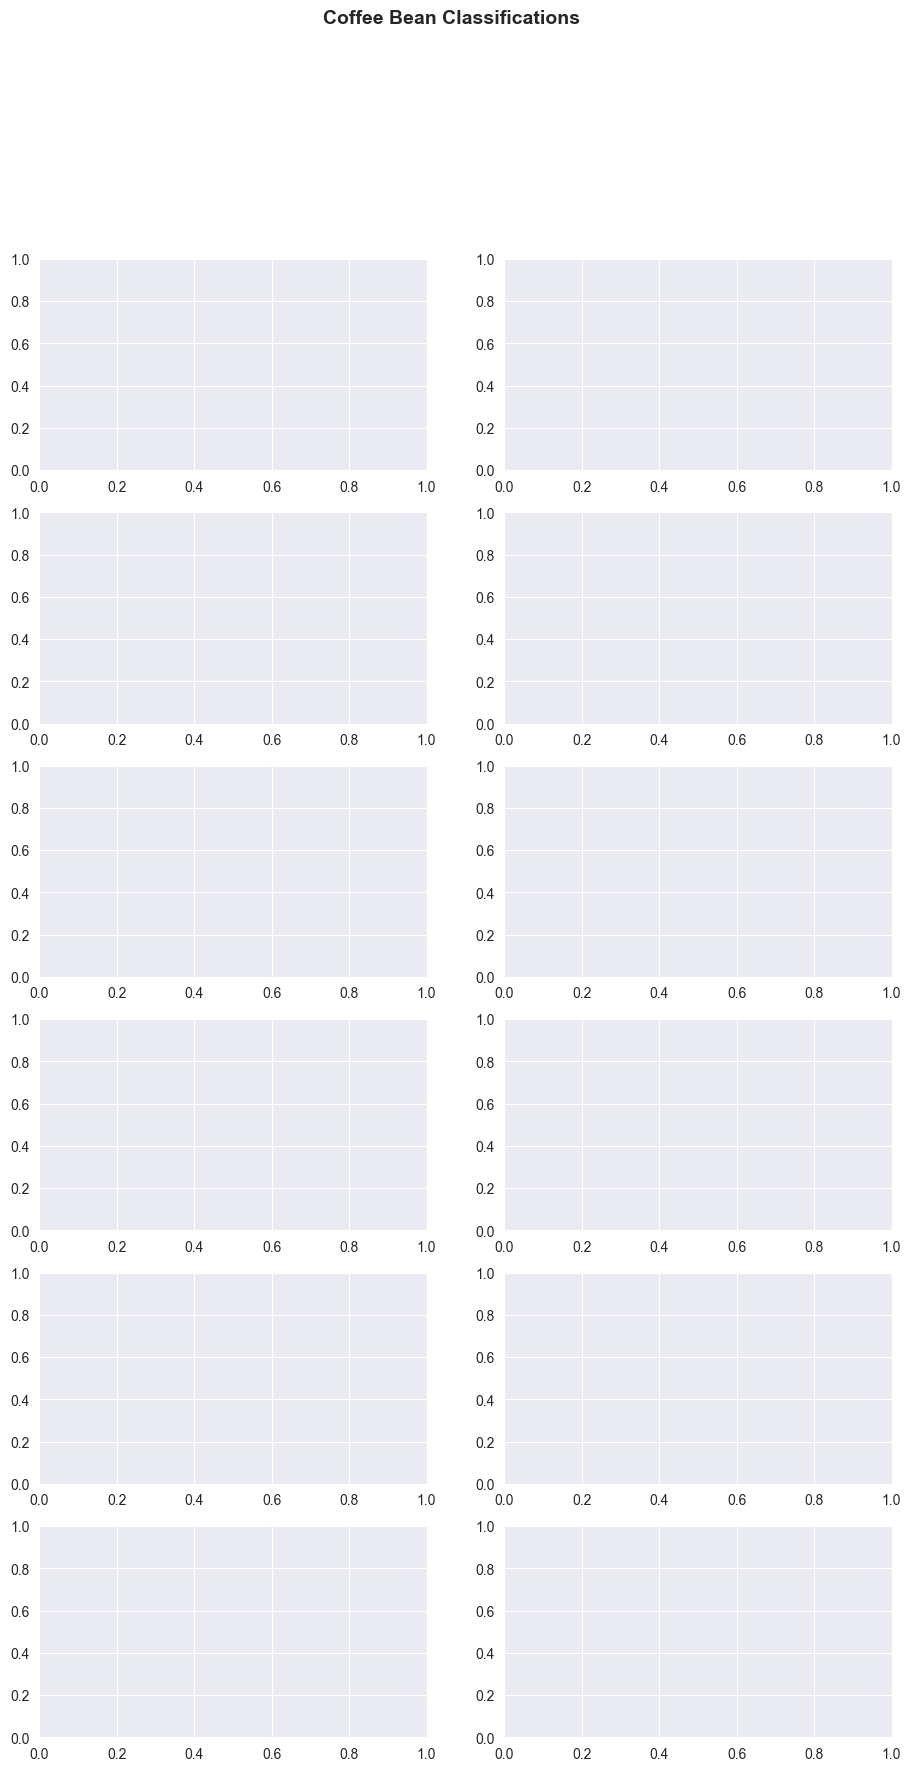

In [44]:
import torch
import torch.nn.functional as F

def show_beans_grid(X_val, y_val, n=6):
    indices = random.sample(range(len(X_val)), n)

    fig, axes = plt.subplots(n, 2, figsize=(11, n * 3.2))

    # guarantee axes is always 2D even if n=1
    if n == 1:
        axes = [axes]

    fig.suptitle("Coffee Bean Classifications", fontsize=14, fontweight="bold", y=1.01)

    for row, idx in enumerate(indices):
        img = Image.open(X_val[idx]).convert("RGB")
        tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feats   = resnet(tensor).cpu()
            img_vec = img_proj(feats)

            similarities = {
                label: F.cosine_similarity(img_vec, projected_text[label], dim=1).item()
                for label in le.classes_
            }

        predicted  = max(similarities, key=similarities.get)
        true_label = y_val[idx]
        profile    = taste_profiles[predicted]
        correct    = predicted == true_label

        ax_img = axes[row][0]   # ← use [row][0] not [row, 0]
        ax_bar = axes[row][1]

        # ── image ─────────────────────────────────────────
        ax_img.imshow(np.array(img))  # ← explicit np.array conversion
        ax_img.axis("off")
        ax_img.set_title(f"Predicted: {predicted}", fontsize=11,
                         fontweight="bold", pad=6)
        ax_img.set_xlabel(f"True: {true_label}",
                          color="green" if correct else "red", fontsize=10)

        # ── bars ──────────────────────────────────────────
        labels = list(similarities.keys())
        scores = [similarities[l] for l in labels]
        colors = ["#E8593C" if l == predicted else "#D0CFC8" for l in labels]

        bars = ax_bar.barh(labels, scores, color=colors, height=0.5)
        ax_bar.set_xlim(0, max(scores) * 1.25)
        ax_bar.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
        ax_bar.set_title(f'"{profile}"', fontsize=9, style="italic", color="#555")
        ax_bar.spines[["top", "right", "left", "bottom"]].set_visible(False)
        ax_bar.tick_params(left=False, bottom=False)
        ax_bar.set_yticklabels(labels, fontsize=9)

    plt.tight_layout()
    plt.show()

show_beans_grid(X_val, y_val, n=6)

---

Sample embedding — true class: Light
Embedding (first 5 dims): tensor([0.7270, 0.7270, 0.0230, 1.6330, 0.4750])


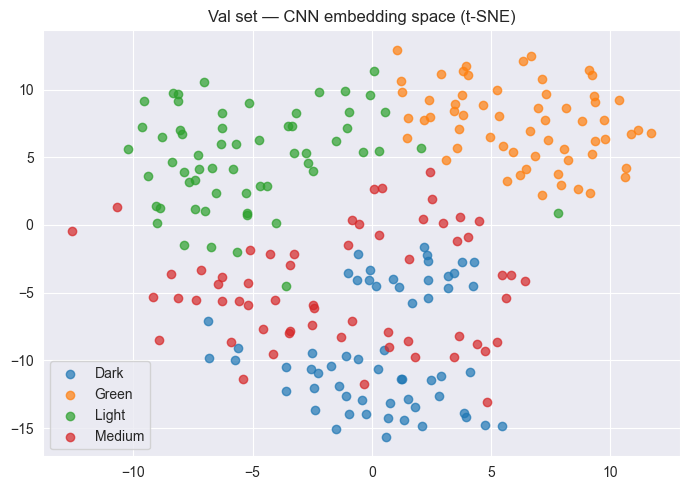

In [39]:
# ── 7. Quick sanity check ────────────────────────────────────
# Confirm a random val image maps to the right class
import random
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

idx = random.randint(0, len(val_emb) - 1)
label_idx = val_labels[idx].item()
print(f"Sample embedding — true class: {le.classes_[label_idx]}")
print(f"Embedding (first 5 dims): {val_emb[idx][:5].round(decimals=3)}")

# t-SNE of image embeddings coloured by class
proj = TSNE(n_components=2, random_state=42).fit_transform(val_emb.numpy())

plt.figure(figsize=(7, 5))
for i, cls in enumerate(le.classes_):
    mask = val_labels.numpy() == i
    plt.scatter(proj[mask, 0], proj[mask, 1], label=cls, alpha=0.7)
plt.legend()
plt.title("Val set — CNN embedding space (t-SNE)")
plt.tight_layout()
plt.show()